In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "examples/gaussian/config.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the model_comparison_new repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from examples.gaussian.analysis.plot import load_runs, plot_metric_grid


In [2]:
NUM_OBS = 10
RESULT_DIR = ROOT / "examples/gaussian/results"
OUTPUT_DIR = RESULT_DIR / "plots" / f"n{NUM_OBS}"

indirect = load_runs("indirect", NUM_OBS, result_dir=RESULT_DIR,
                     summary_dims=(20, 40, 80))
direct = load_runs("direct", NUM_OBS, result_dir=RESULT_DIR,
                   summary_dims=(12,),
                   scoring_rules=("cross_entropy", "logistic", "exponential"))

# Check dataset identity across both methods before comparing figures.
key_columns = ["source_model", "id", "candidate_model"]
reference = next(iter(indirect.values())).set_index(key_columns).sort_index()
for label, frame in direct.items():
    aligned = frame.set_index(key_columns).sort_index()
    if not aligned.index.equals(reference.index):
        raise ValueError(f"Direct/indirect dataset mismatch: {label}")
    if "gold_pmp" in aligned and "gold_pmp" in reference:
        pd.testing.assert_series_equal(aligned.gold_pmp, reference.gold_pmp,
                                       check_exact=False, rtol=1e-10, atol=1e-12)

print("Indirect:", ", ".join(indirect))
print("Direct:", ", ".join(direct))
print("Figures:", OUTPUT_DIR)


Indirect: S=D, S=2D, S=4D
Direct: Cross-entropy (S=12), Logistic (S=12), Exponential (S=12)
Figures: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10


## Indirect: posterior MMD

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/posterior_mmd_4x4.png


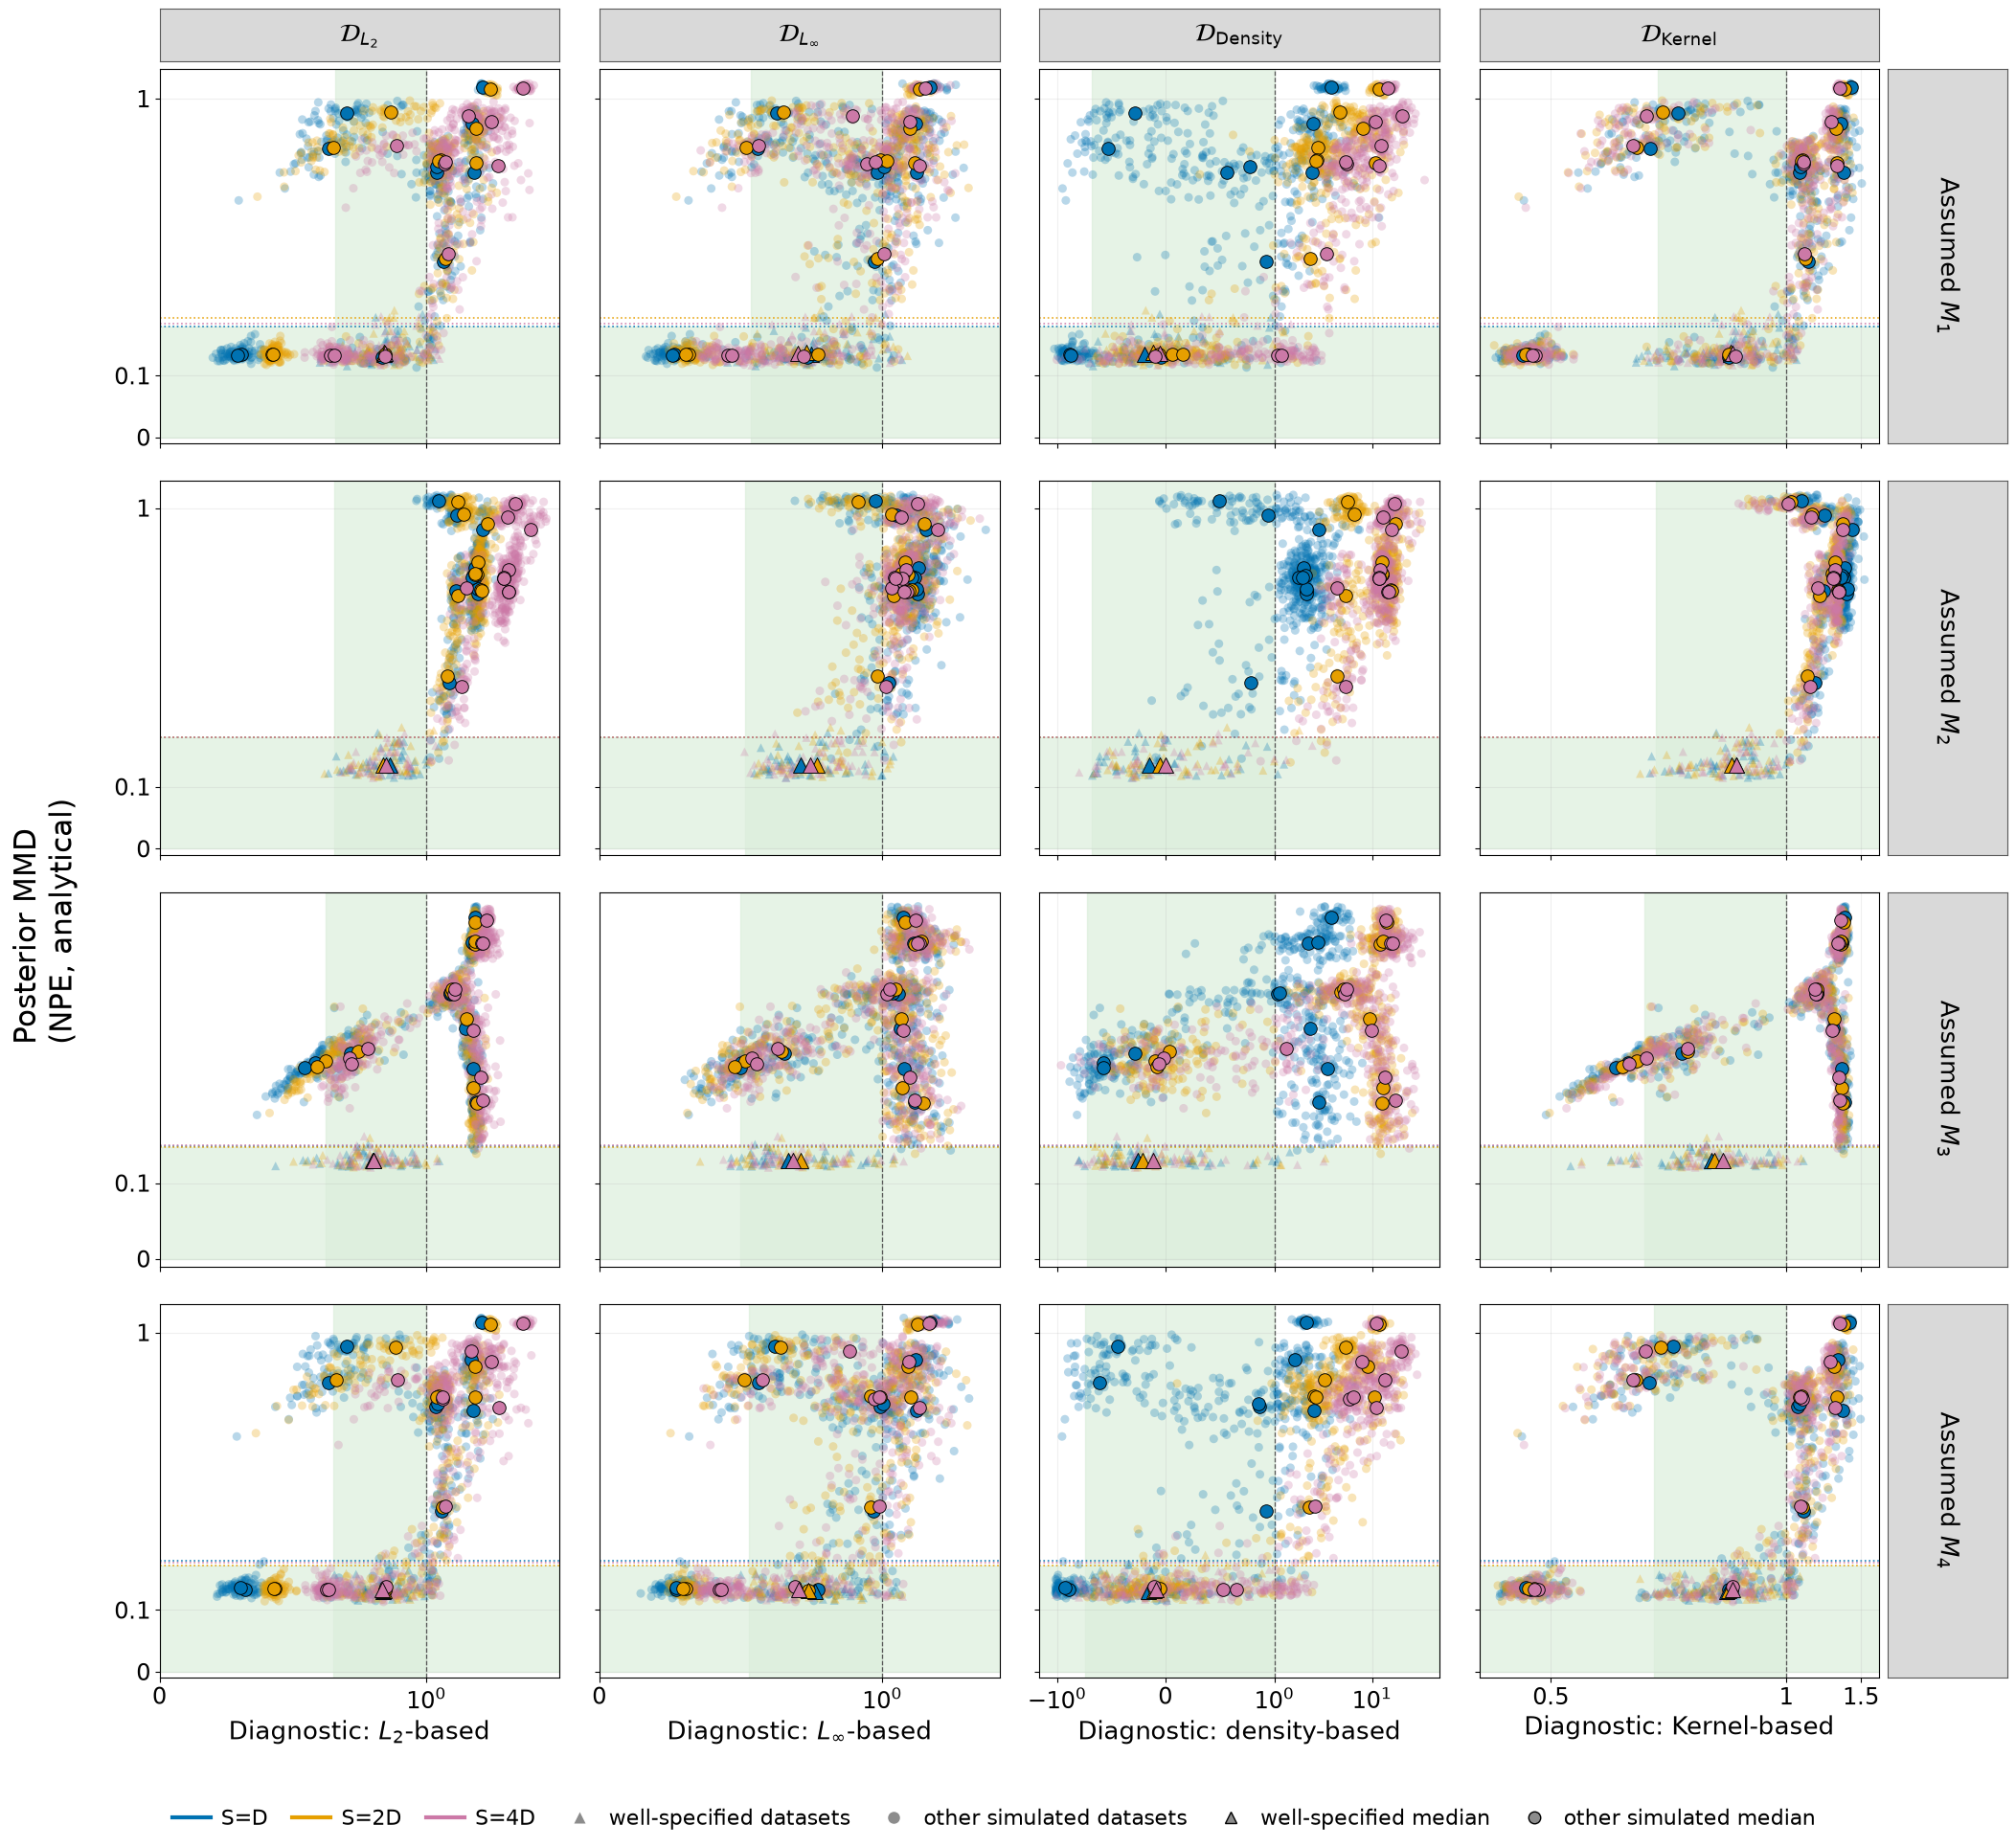

In [3]:
fig, axes = plot_metric_grid(
    indirect, "posterior_mmd",
    output=OUTPUT_DIR / "indirect" / "posterior_mmd_4x4.png",
)
display(fig)
plt.close(fig)


## Indirect: log10 marginal-likelihood error

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/logml_4x4.png


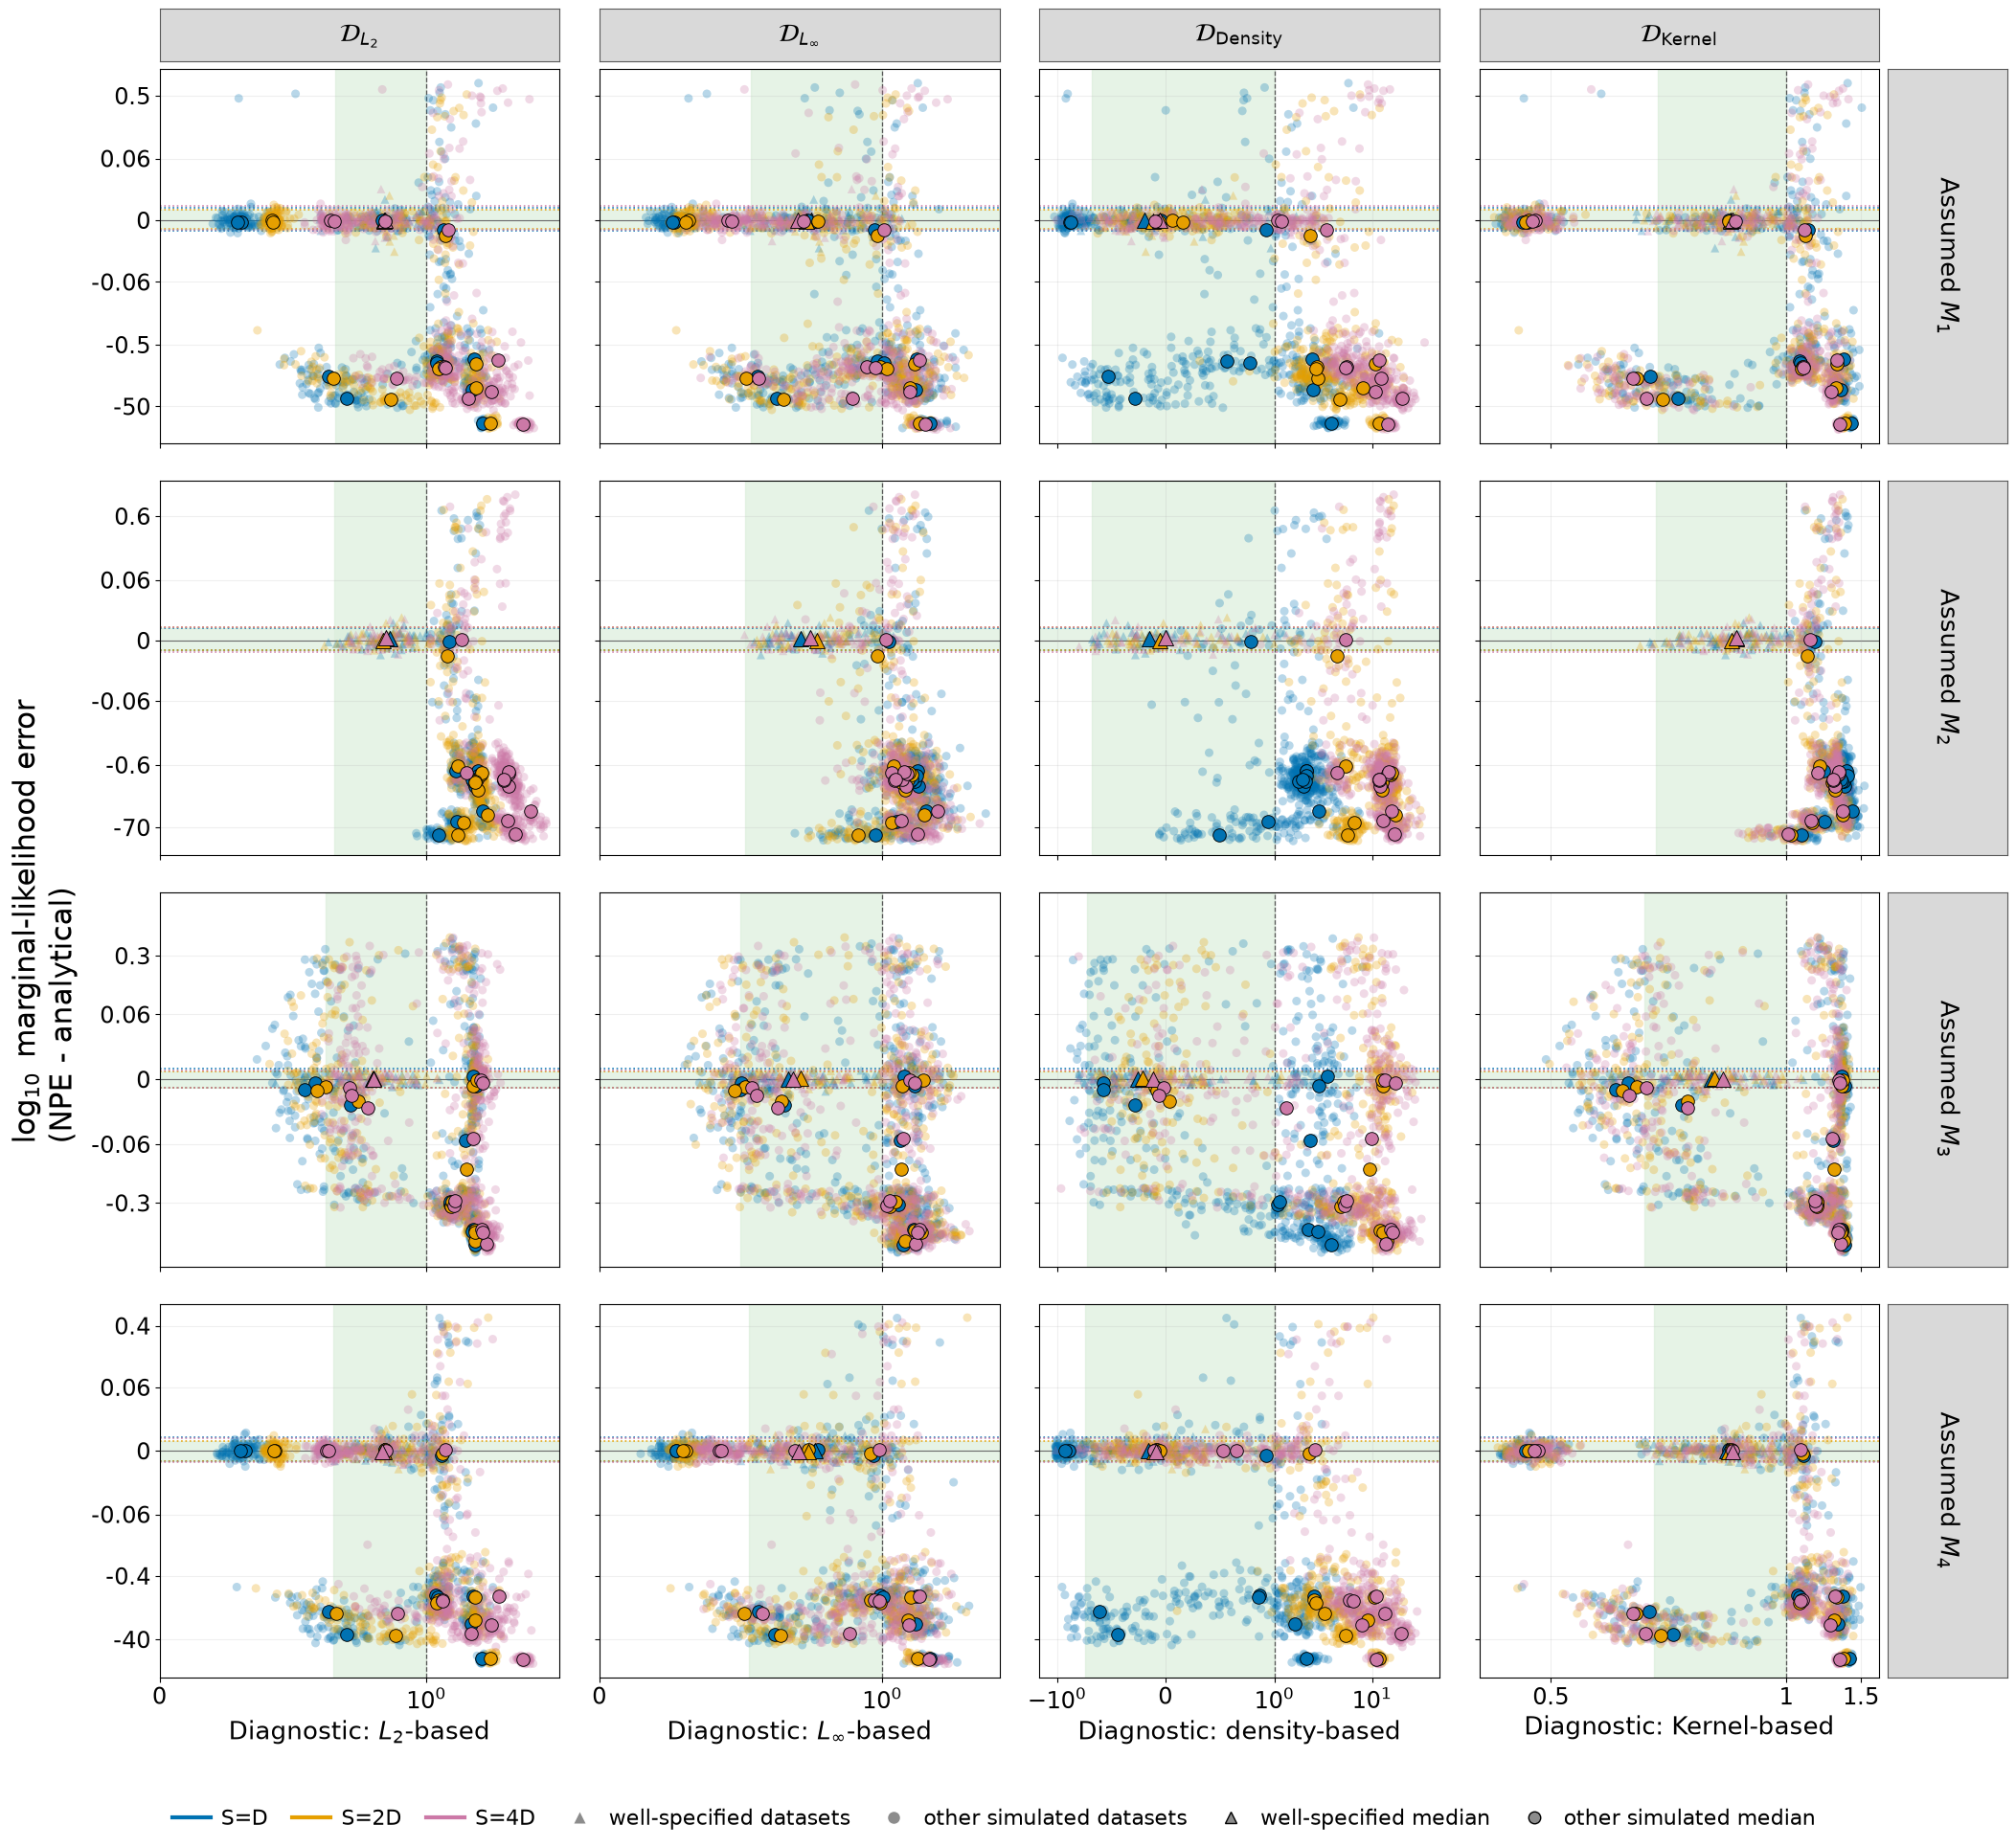

In [4]:
fig, axes = plot_metric_grid(
    indirect, "logml",
    output=OUTPUT_DIR / "indirect" / "logml_4x4.png",
)
display(fig)
plt.close(fig)


## Indirect: PMP error

Circles: all four candidates have rho > 1. Diamonds: at least one candidate has rho <= 1. This classification is recomputed from the saved rho columns, not from error thresholds.

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/indirect/pmp_4x4.png


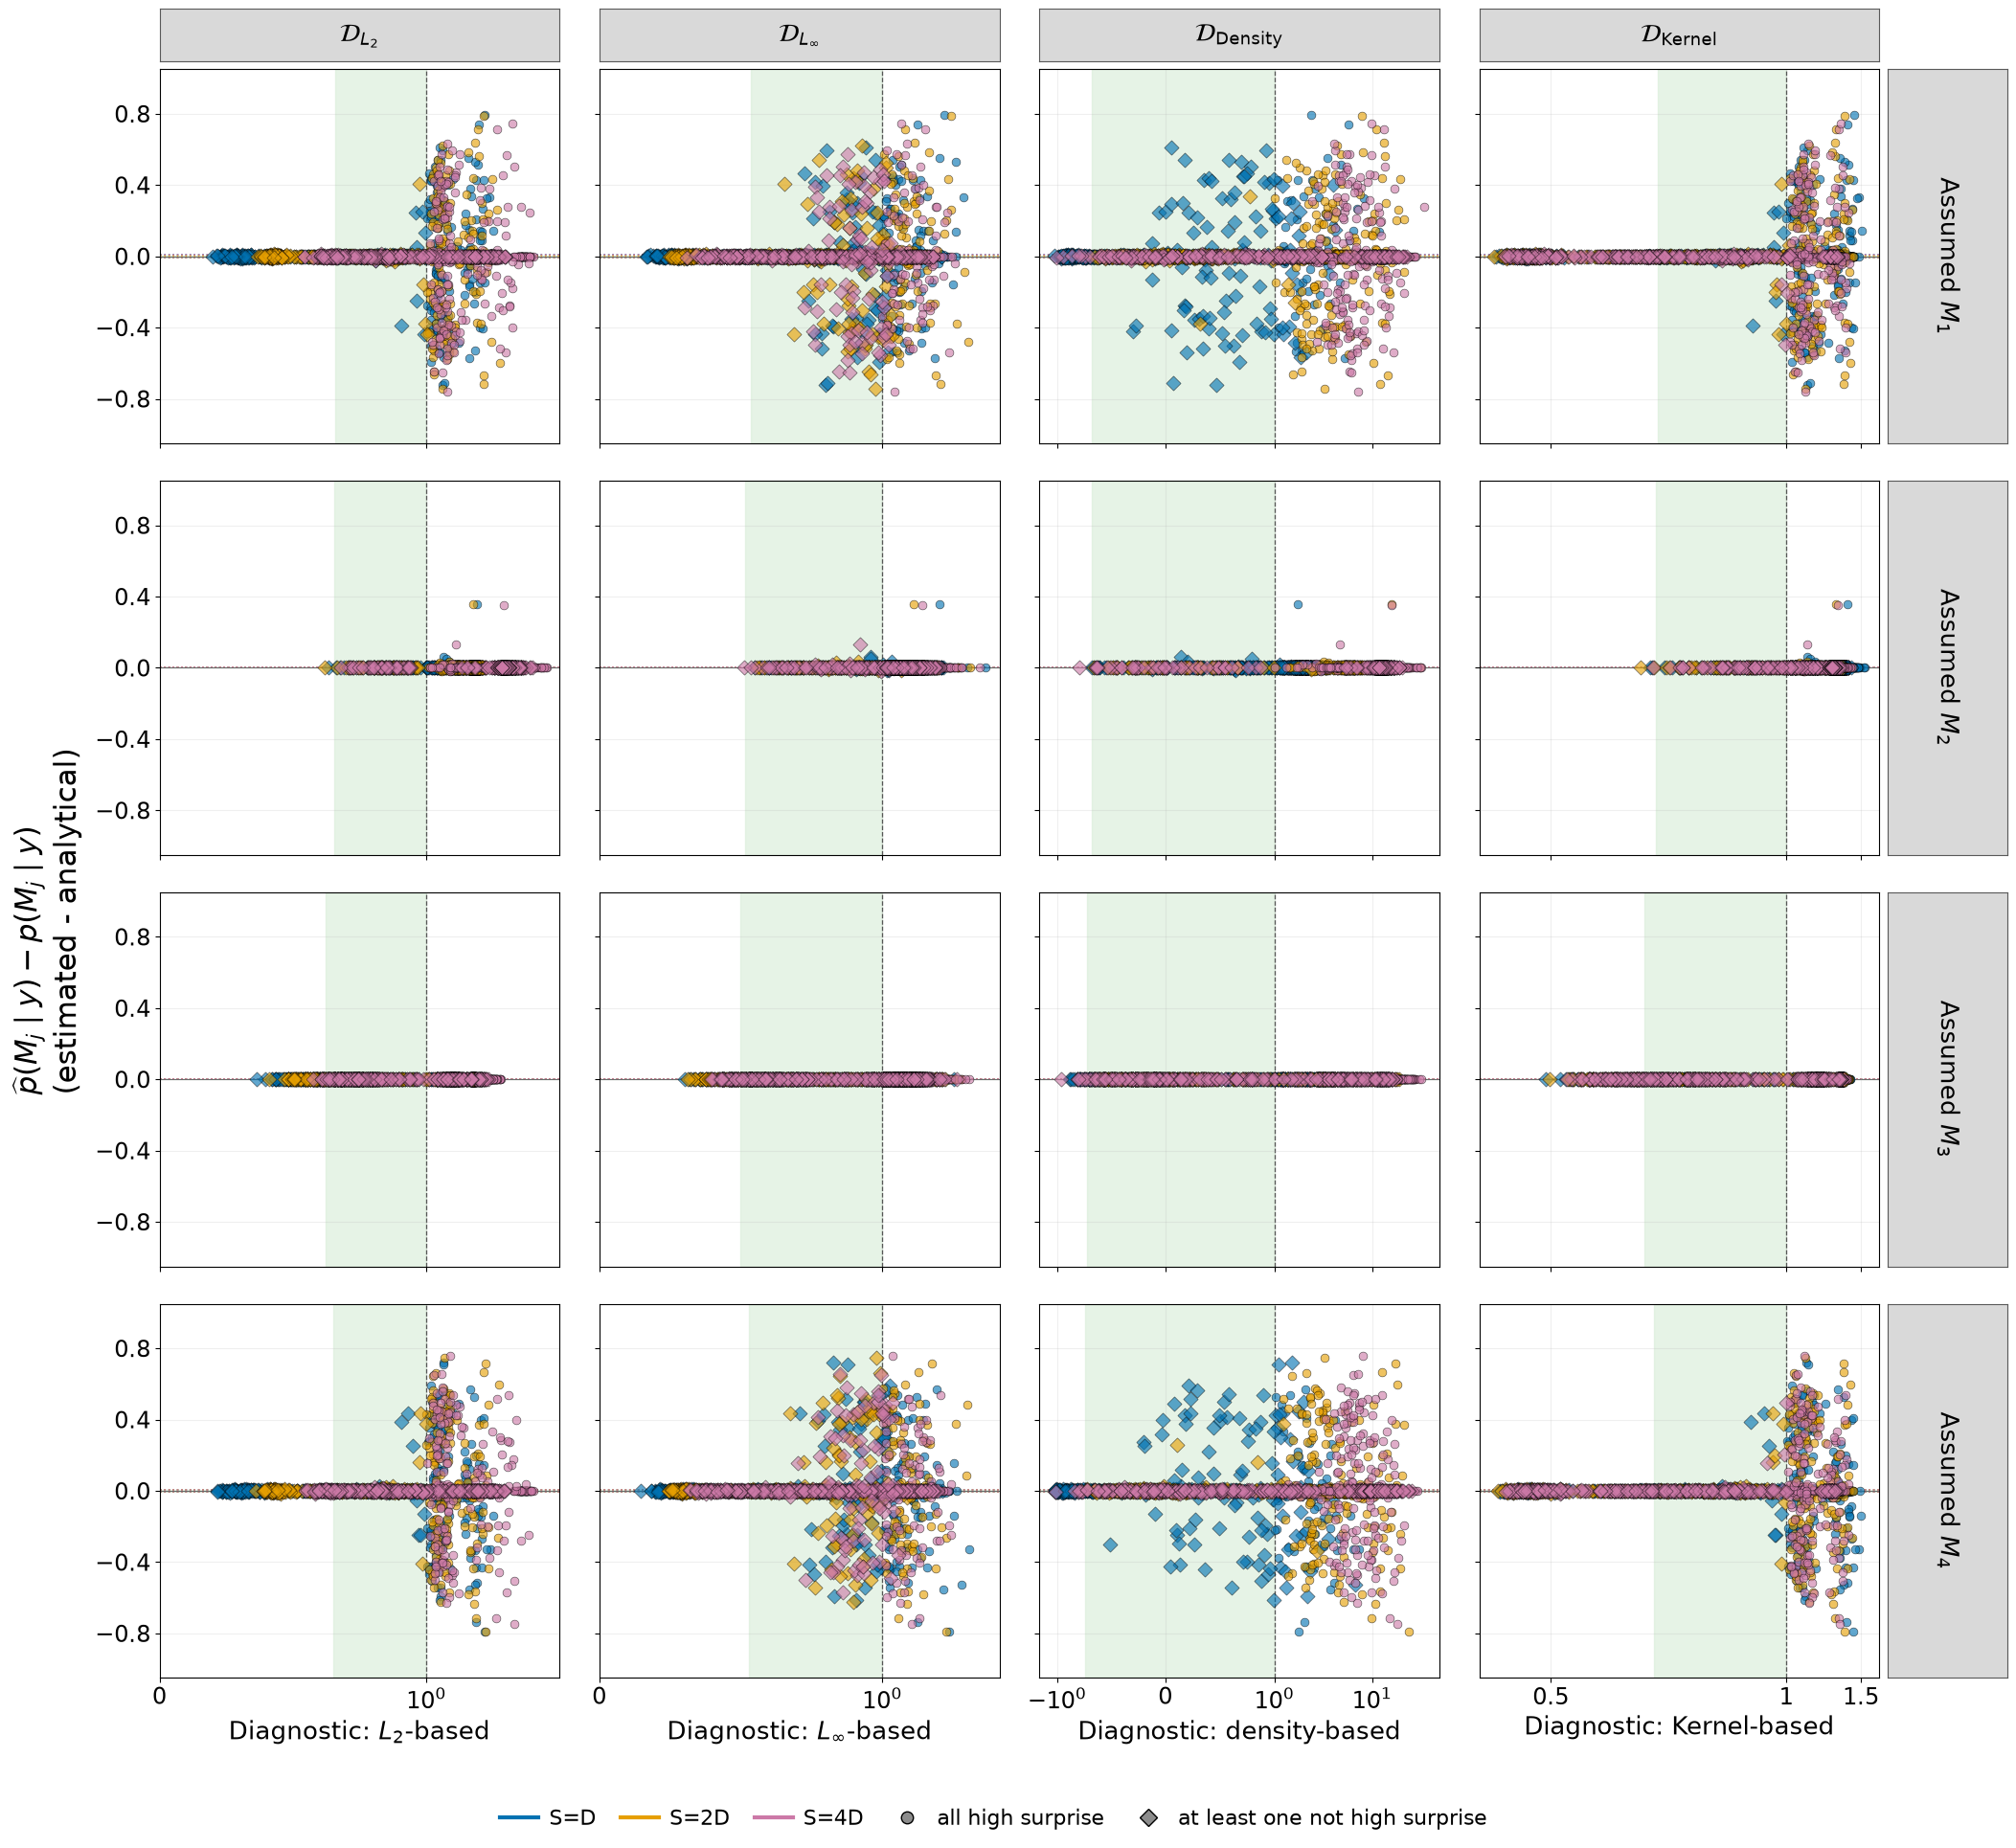

In [5]:
fig, axes = plot_metric_grid(
    indirect, "pmp",
    output=OUTPUT_DIR / "indirect" / "pmp_4x4.png",
    ylim=(-1.05, 1.05),
)
display(fig)
plt.close(fig)


## Direct: PMP error

Color encodes scoring rule. All points use a common marker; there is no cross-model surprise classification. For each dataset and loss, the same diagnostic x-value appears in all four PMP rows.

Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/direct/pmp_4x4.png


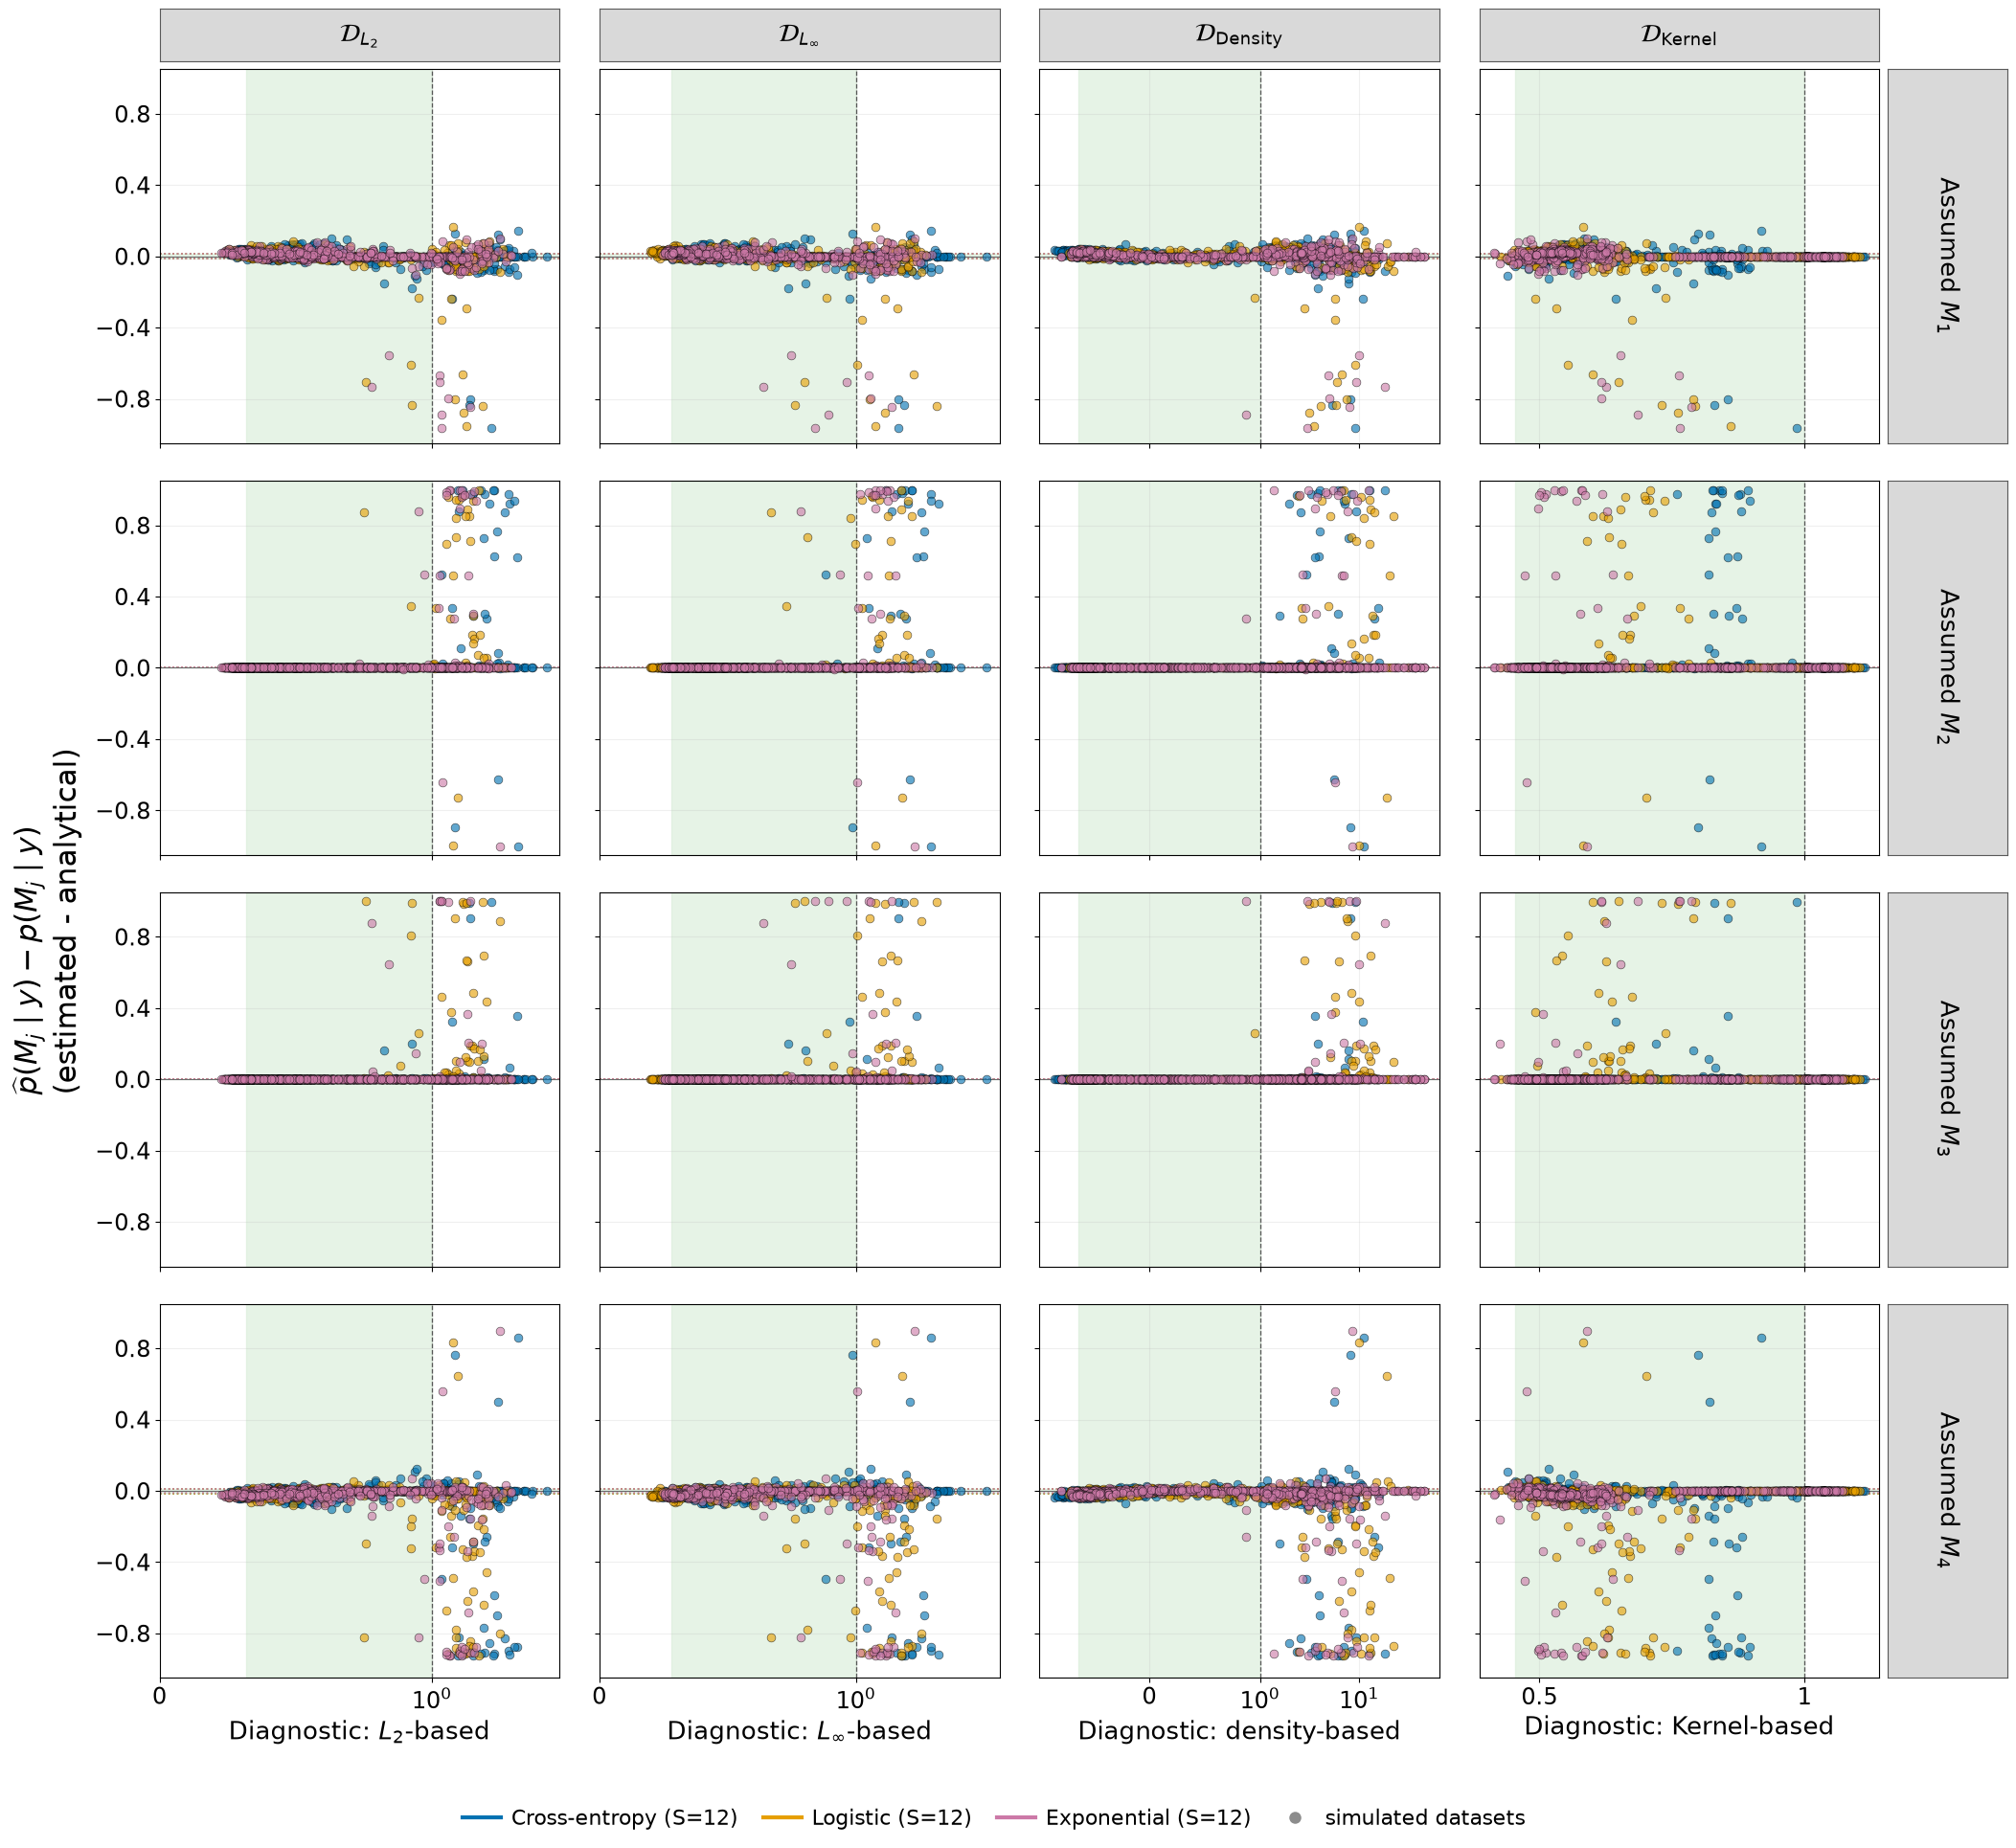

In [6]:
fig, axes = plot_metric_grid(
    direct, "pmp",
    output=OUTPUT_DIR / "direct" / "pmp_4x4.png",
    ylim=(-1.05, 1.05),
)
display(fig)
plt.close(fig)


## Posterior model probability recovery

Indirect PMP (S=4D) and each direct loss are compared with the same gold-standard PMP.


Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/recovery/pmp_recovery_all_losses_all.png
Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/recovery/pmp_recovery_all_losses_all.pdf


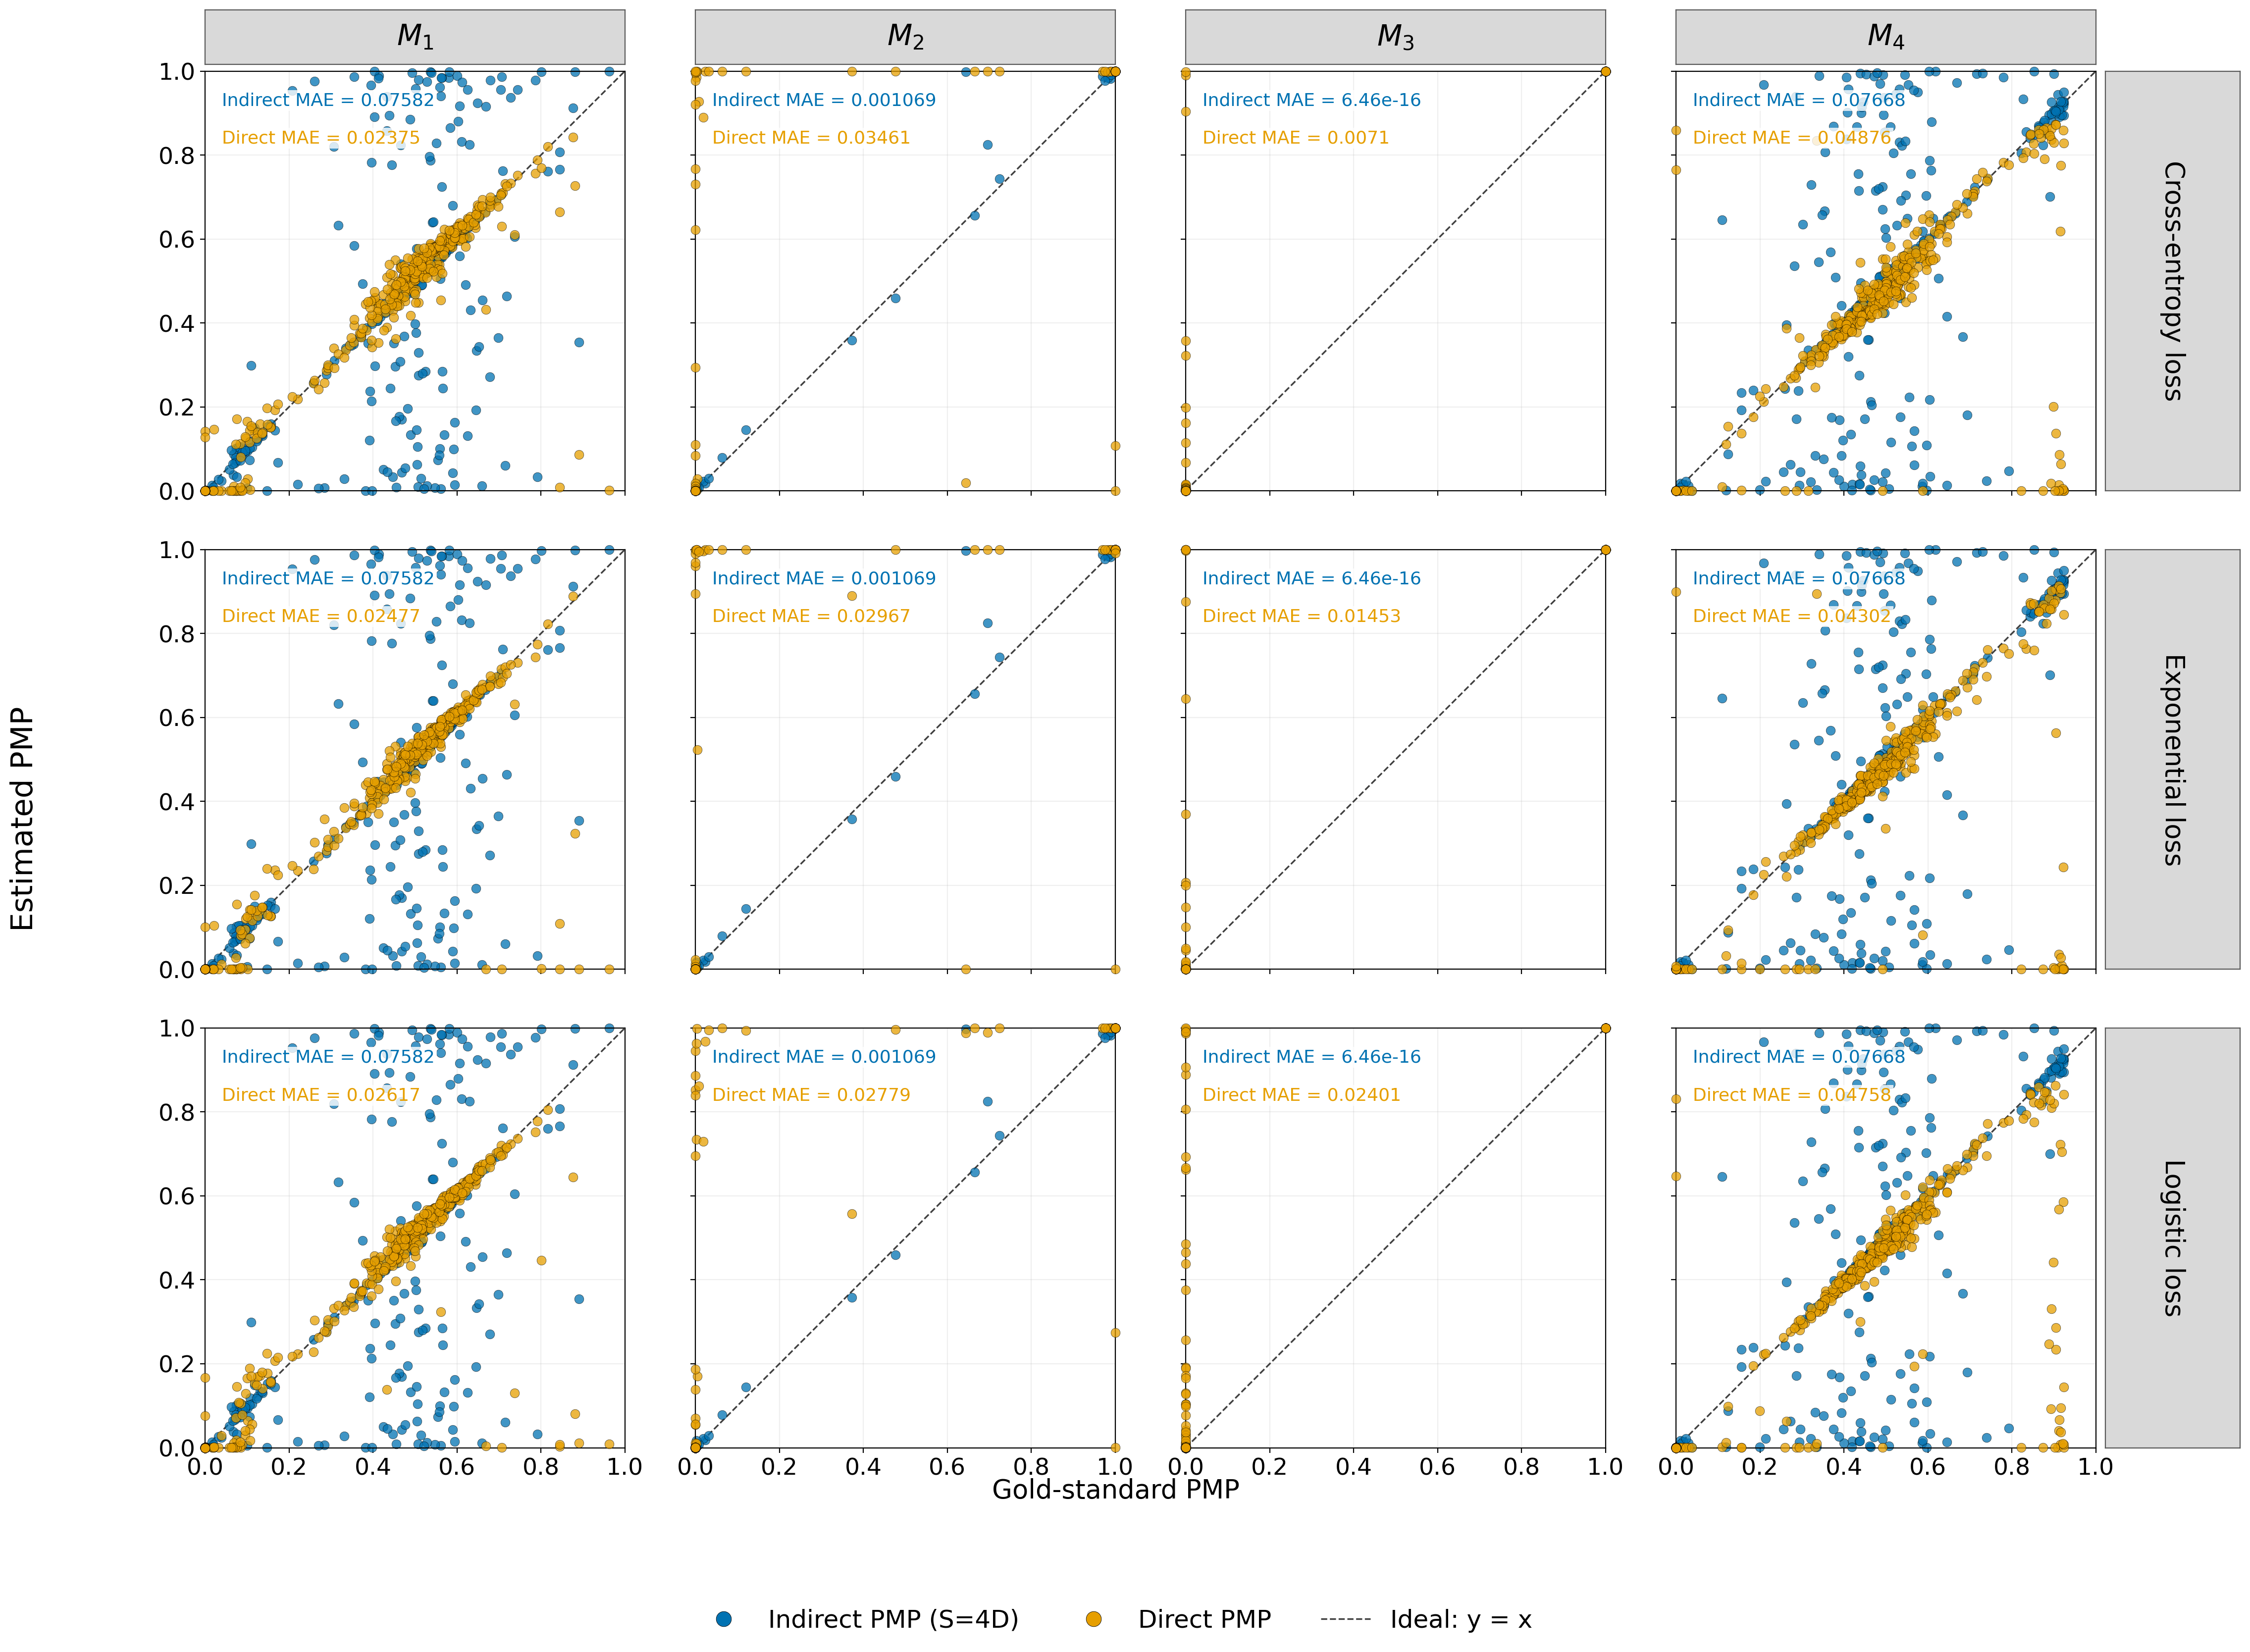

In [7]:
from examples.gaussian.analysis.plot import (
    load_pmp_recovery_data, plot_pmp_recovery, plot_pmp_recovery_by_source,
)

recovery = load_pmp_recovery_data(indirect, direct, summary_dim=80)
RECOVERY_DIR = OUTPUT_DIR / "recovery"
fig, axes = plot_pmp_recovery(
    recovery, output_stem=RECOVERY_DIR / "pmp_recovery_all_losses_all",
)
display(fig)
plt.close(fig)


## Recovery by source model

Point color identifies the generating model; circles show indirect PMP and triangles show direct PMP.


Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/recovery/pmp_recovery_by_source_all.png
Saved: /Users/yimingzang/Documents/Project/model_comparison/examples/gaussian/results/plots/n10/recovery/pmp_recovery_by_source_all.pdf


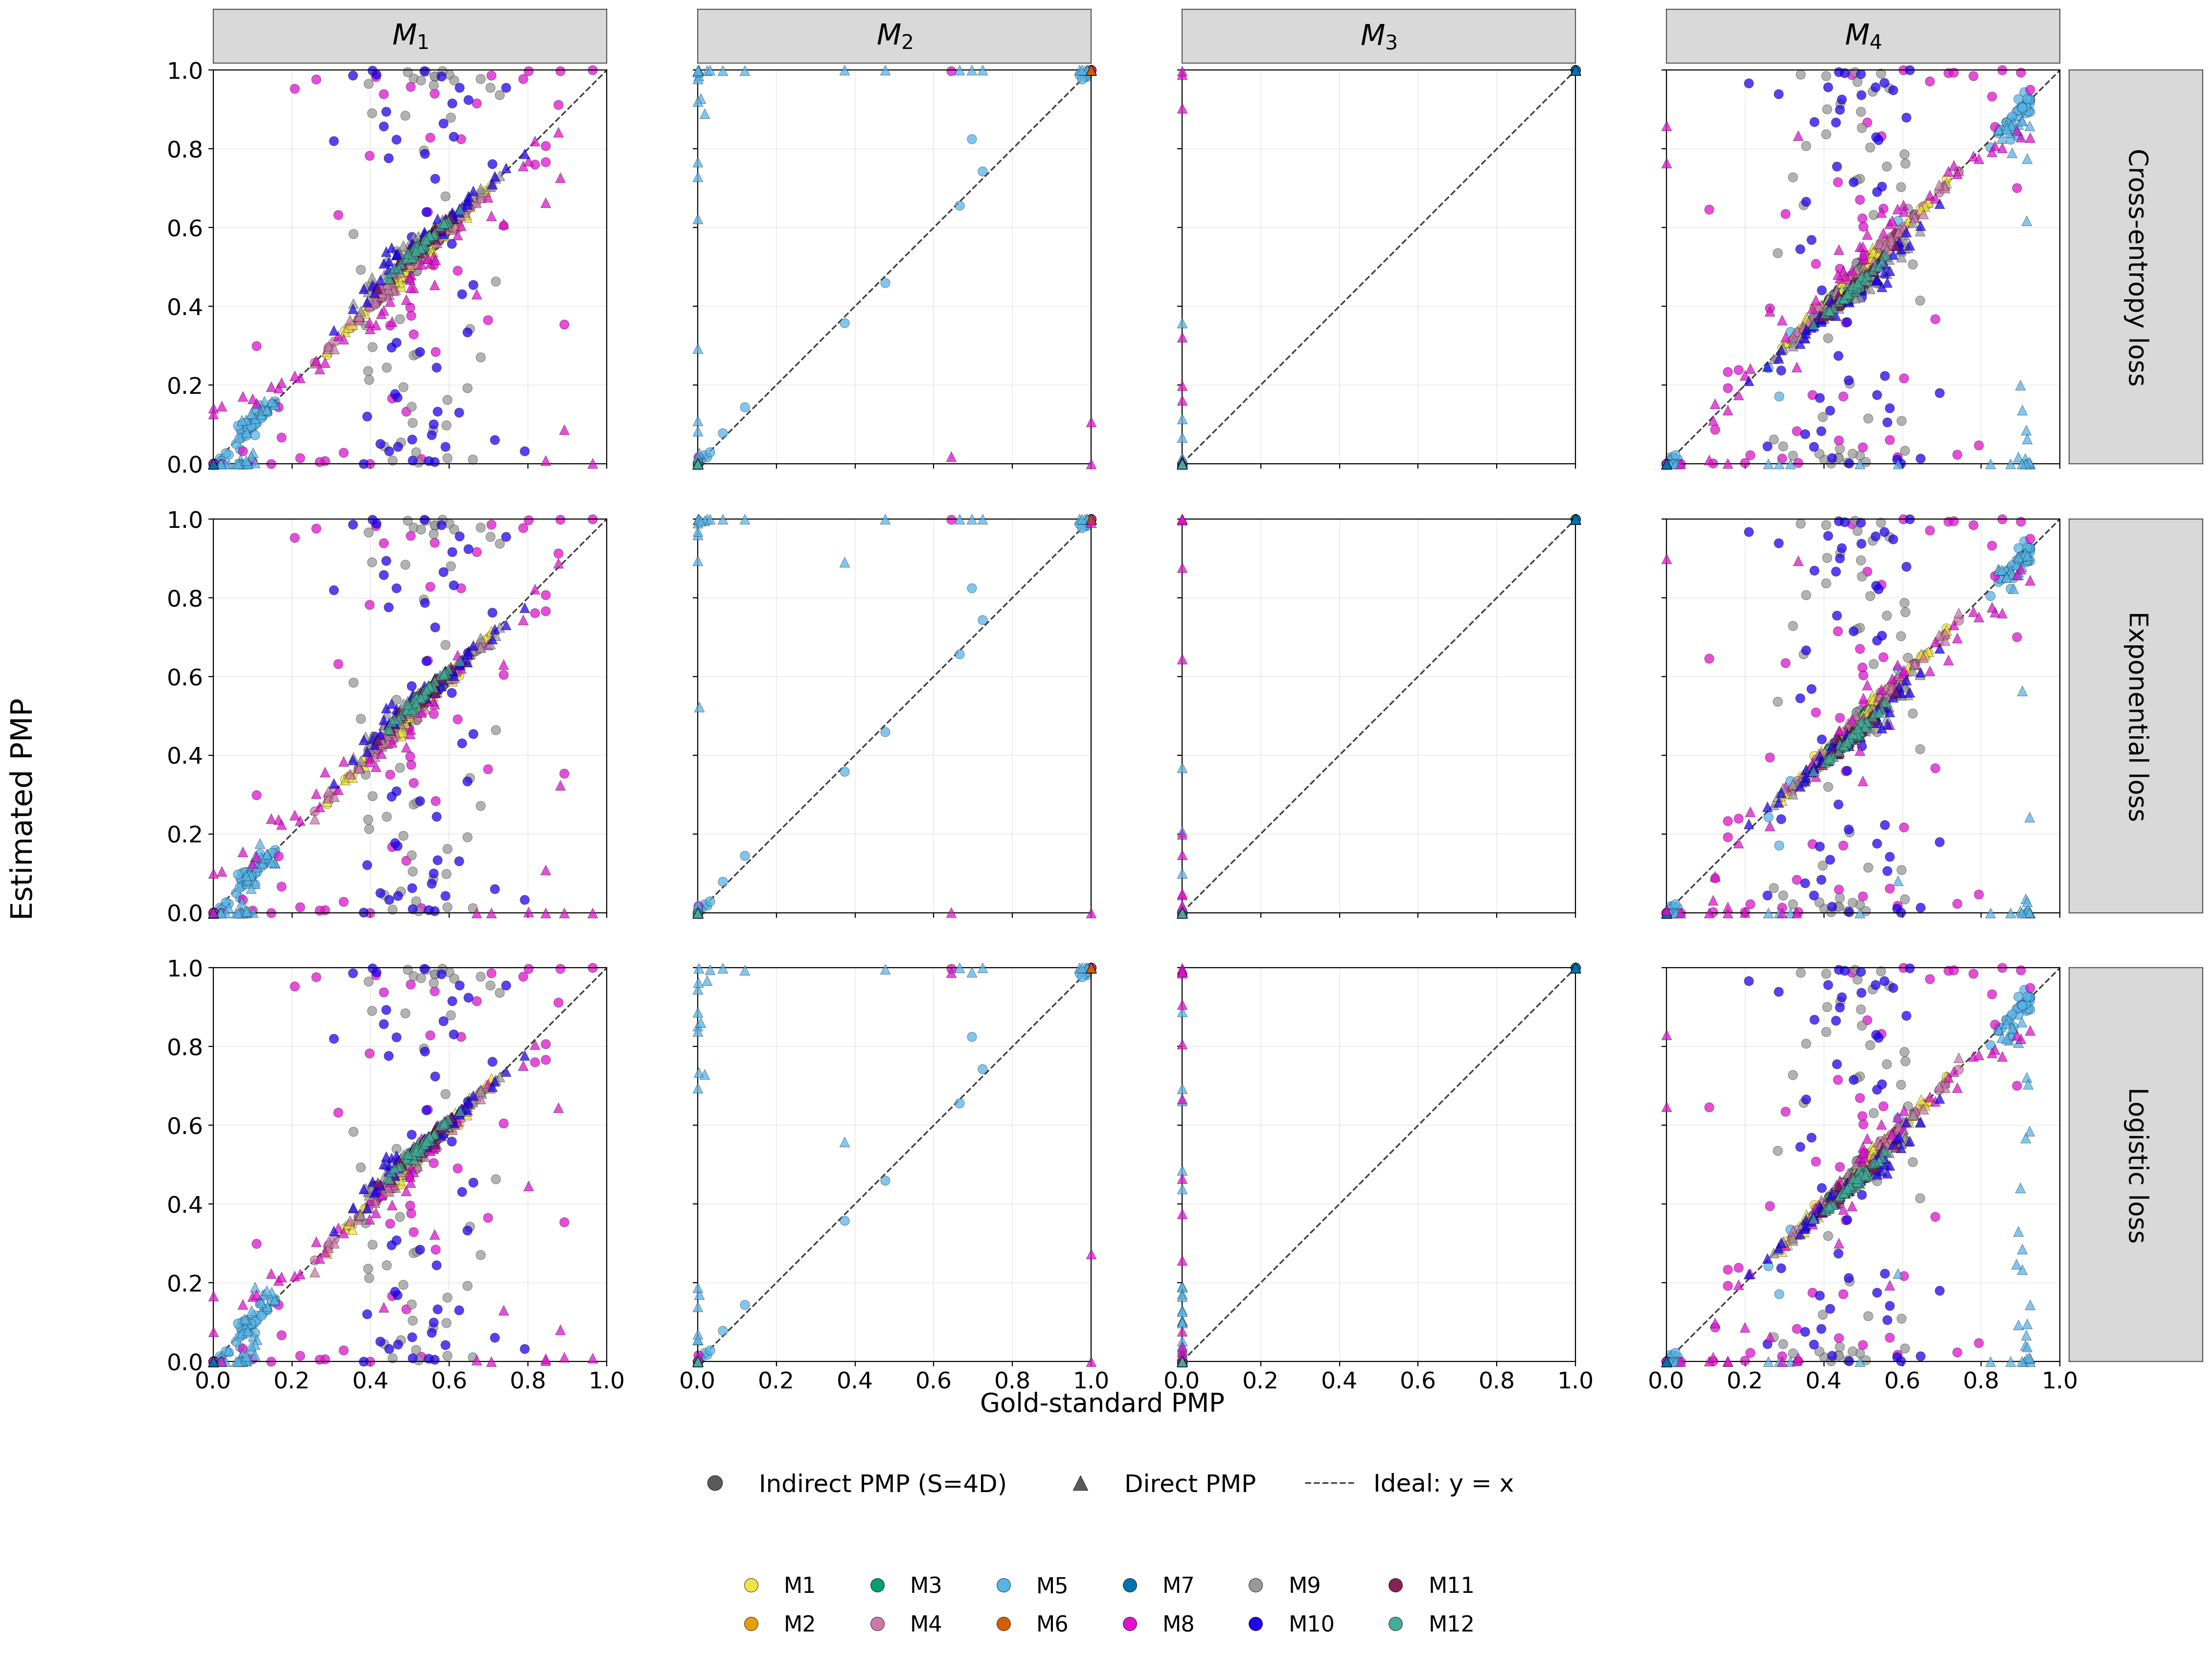

In [8]:
fig, axes = plot_pmp_recovery_by_source(
    recovery, output_stem=RECOVERY_DIR / "pmp_recovery_by_source_all",
)
display(fig)
plt.close(fig)
